In [2]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка
data = fetch_openml(data_id=31, as_frame=True)
df = data.frame
y = data.target


In [4]:
df

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking,12,existing paid,furniture/equipment,1736,<100,4<=X<7,3,female div/dep/mar,none,...,real estate,31,none,own,1,unskilled resident,1,none,yes,good
996,<0,30,existing paid,used car,3857,<100,1<=X<4,4,male div/sep,none,...,life insurance,40,none,own,1,high qualif/self emp/mgmt,1,yes,yes,good
997,no checking,12,existing paid,radio/tv,804,<100,>=7,4,male single,none,...,car,38,none,own,1,skilled,1,none,yes,good
998,<0,45,existing paid,radio/tv,1845,<100,1<=X<4,4,male single,none,...,no known property,23,none,for free,1,skilled,1,yes,yes,bad


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1000 non-nul

In [6]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [8]:
print(f"Целевая переменная: {y.value_counts()}")

Целевая переменная: class
good    700
bad     300
Name: count, dtype: int64


In [11]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [20]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

Числовые признаки: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Категориальные признаки: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'class']


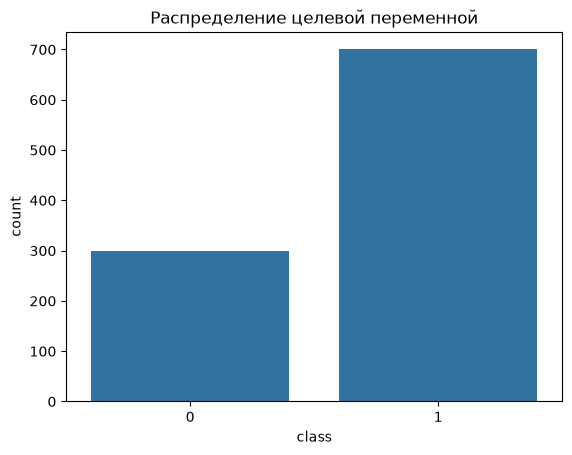

Доля дефолтов: 70.00%


In [25]:
sns.countplot(x=y)
plt.title('Распределение целевой переменной')
plt.show()

print(f"Доля дефолтов: {y.mean():.2%}")

In [26]:
df['target'] = y

In [46]:
num_cols_sort = ['duration','credit_amount','age']

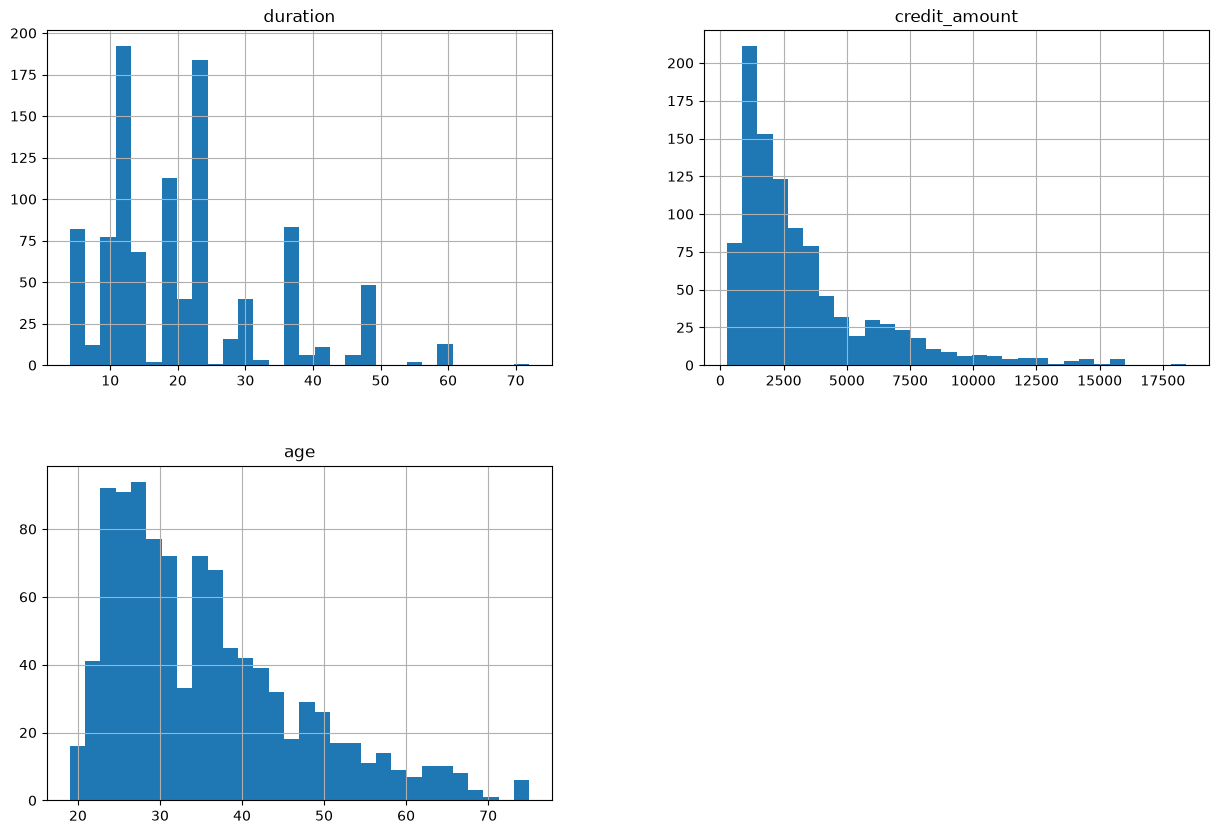

In [47]:
df[num_cols_sort].hist(bins = 30,figsize= (15,10))
plt.show()

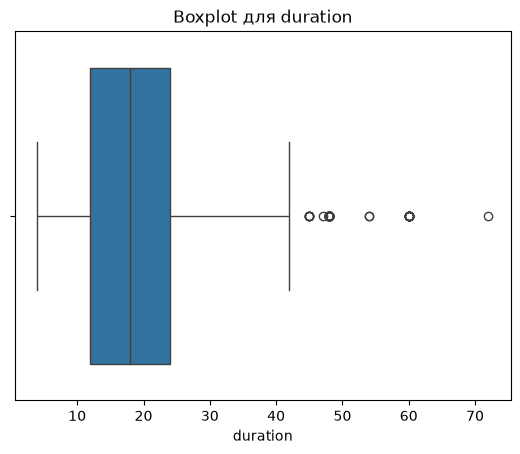

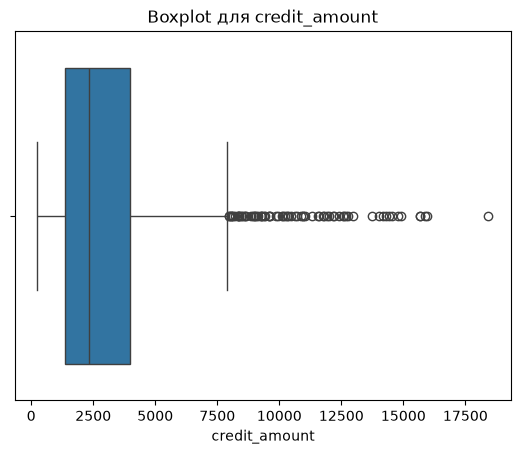

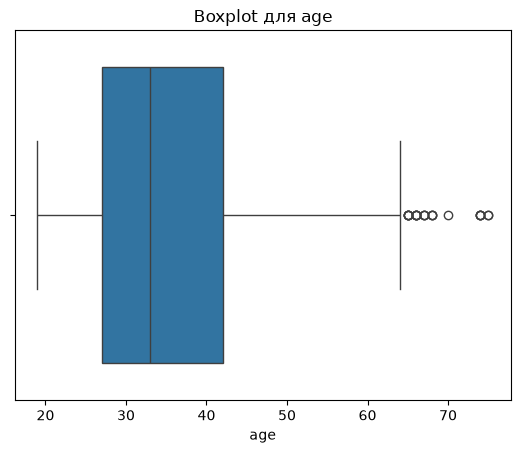

In [48]:
for col in num_cols_sort:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot для {col}')
    plt.show()

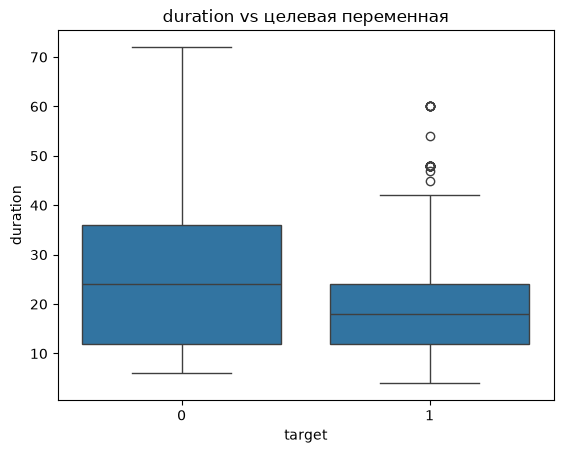

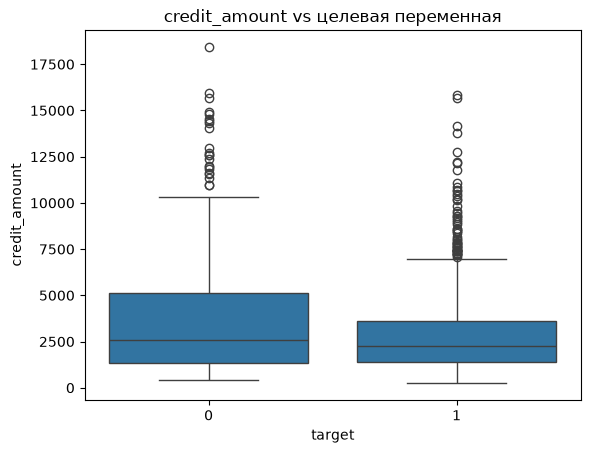

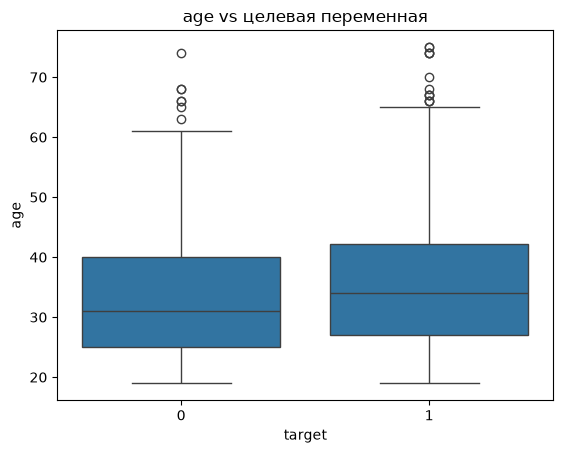

In [49]:
for col in num_cols_sort:
    plt.figure()
    sns.boxplot(x=df['target'], y=df[col])
    plt.title(f'{col} vs целевая переменная')
    plt.show()

In [36]:
corr = df[num_cols].corrwith(pd.Series(y, name='target'))
print(corr.sort_values(ascending=False))

age                       0.091127
existing_credits          0.045732
num_dependents            0.003015
residence_since          -0.002967
installment_commitment   -0.072404
credit_amount            -0.154739
duration                 -0.214927
dtype: float64


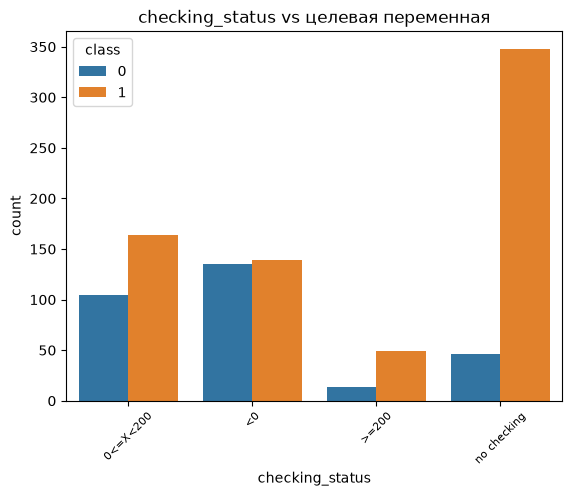

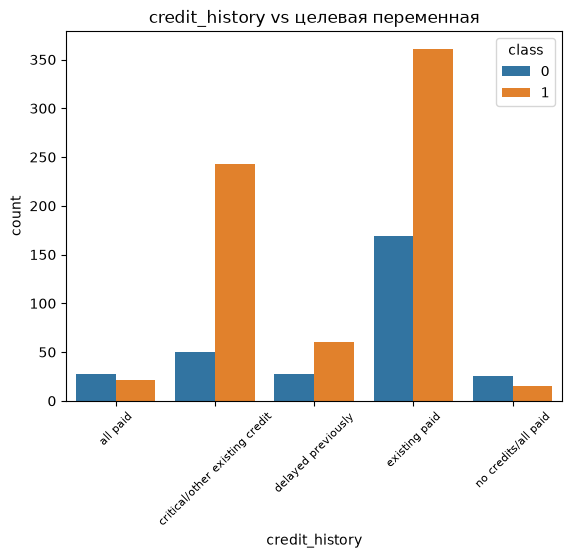

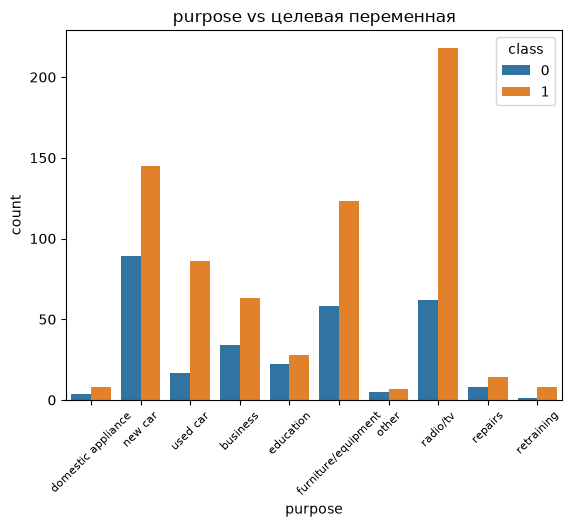

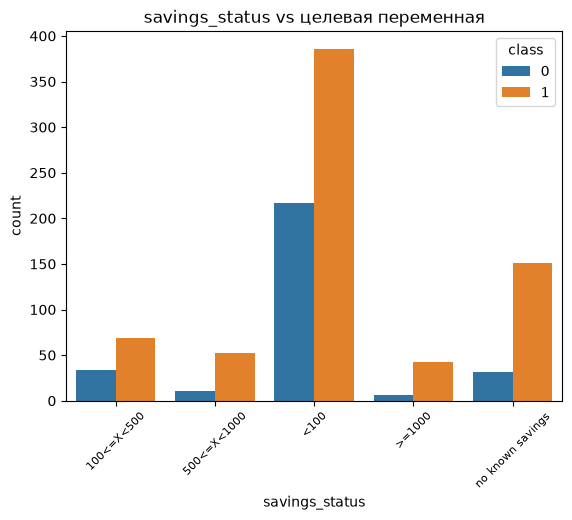

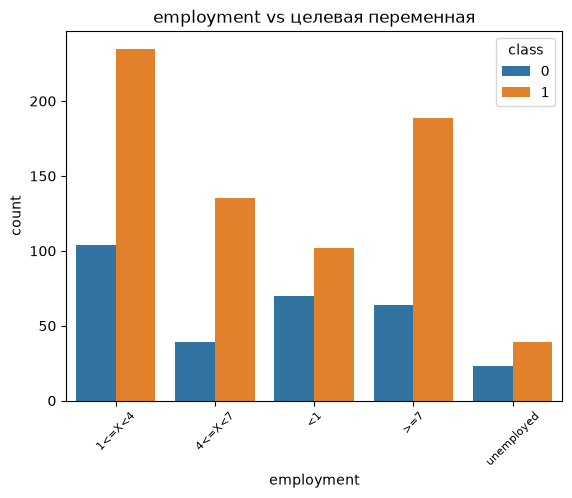

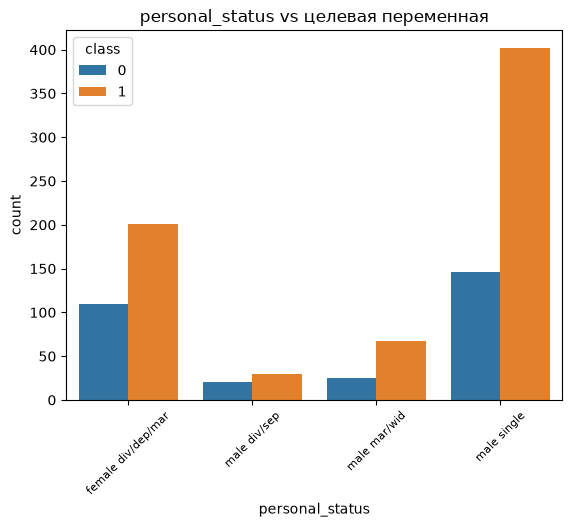

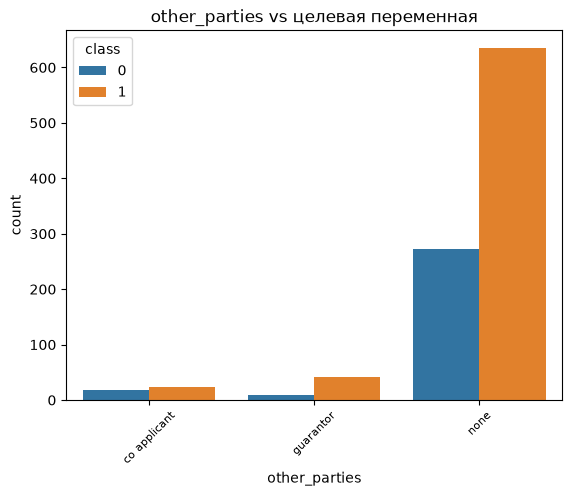

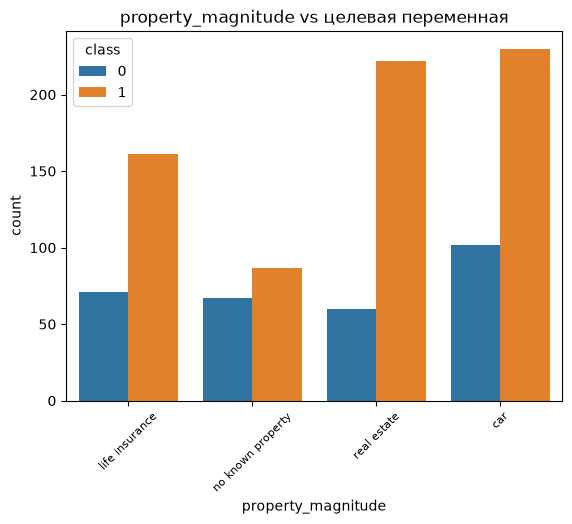

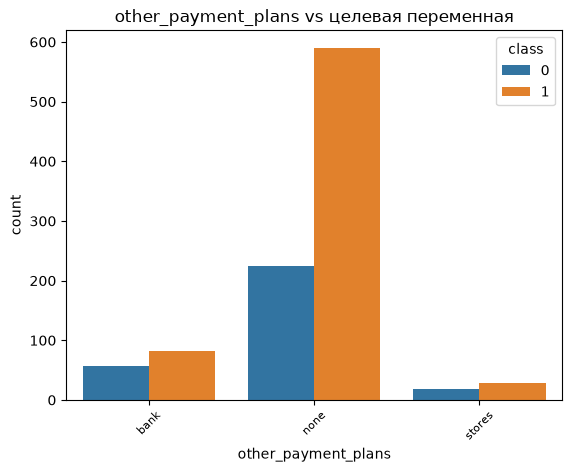

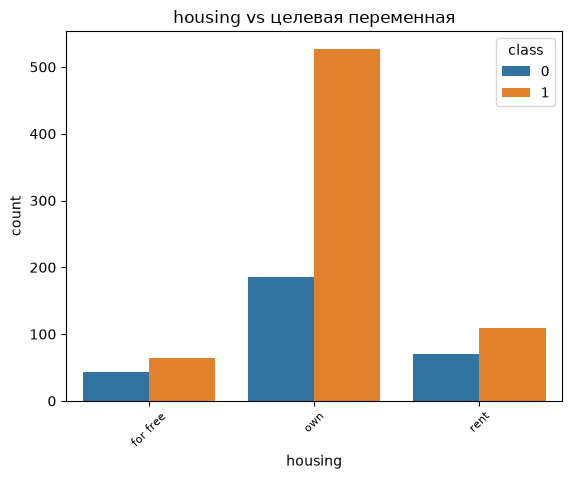

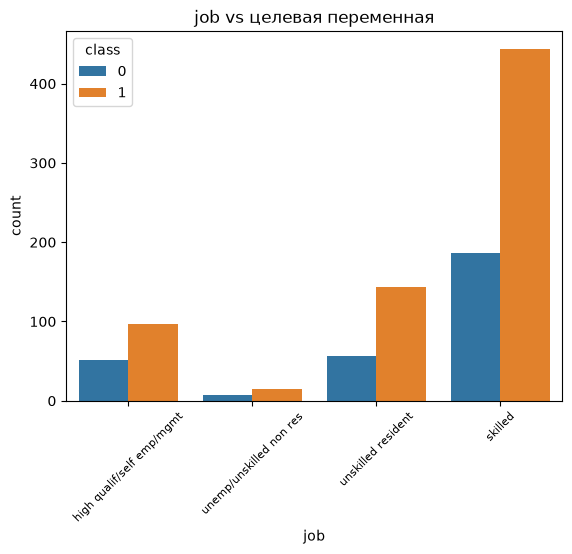

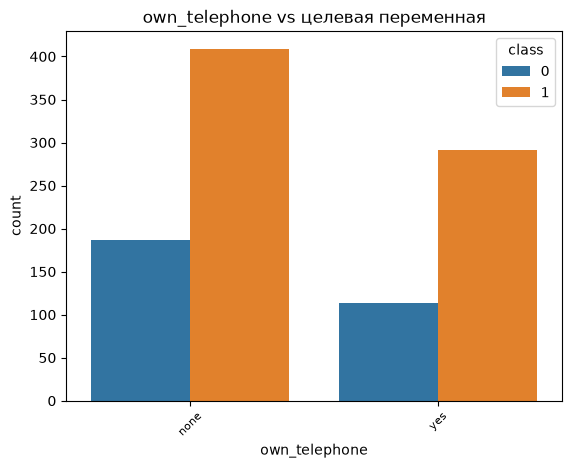

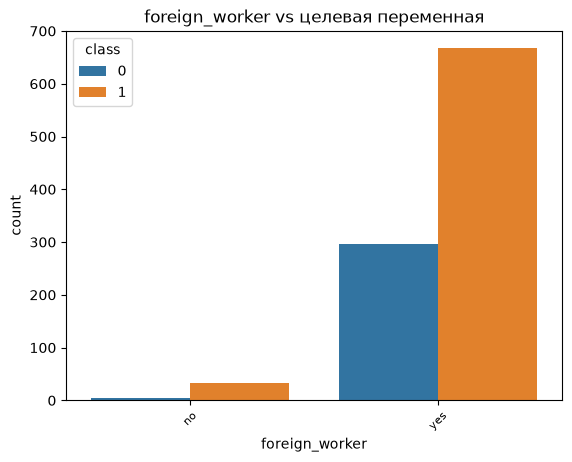

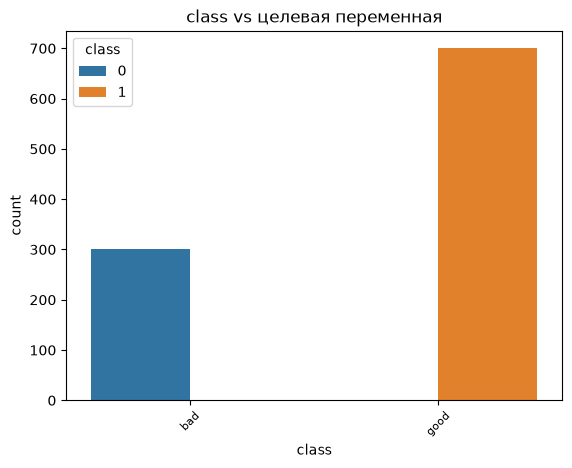

In [39]:
for col in cat_cols:
    sns.countplot(x=df[col], hue=y)
    plt.title(f'{col} vs целевая переменная')
    plt.xticks(rotation=45,fontsize = 8)
    plt.show()

In [53]:
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df.groupby(col)['target'].mean().sort_values(ascending=False))


=== checking_status ===
checking_status
no checking    0.883249
>=200          0.777778
0<=X<200       0.609665
<0             0.507299
Name: target, dtype: float64

=== credit_history ===
credit_history
critical/other existing credit    0.829352
delayed previously                0.681818
existing paid                     0.681132
all paid                          0.428571
no credits/all paid               0.375000
Name: target, dtype: float64

=== purpose ===
purpose
retraining             0.888889
used car               0.834951
radio/tv               0.778571
furniture/equipment    0.679558
domestic appliance     0.666667
business               0.649485
repairs                0.636364
new car                0.619658
other                  0.583333
education              0.560000
Name: target, dtype: float64

=== savings_status ===
savings_status
>=1000              0.875000
500<=X<1000         0.825397
no known savings    0.825137
100<=X<500          0.669903
<100                0.

In [54]:
if 'target' in num_cols: num_cols.remove('target')
if 'target' in cat_cols: cat_cols.remove('target')

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [90]:
X = df.drop(['target','class'],axis = 1)
y=df['target']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [1]:
# Логарифмическое преобразование
def log_transform(x):
    return np.log1p(x)  # log(1+x) защищает от нулей

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('log', FunctionTransformer(log_transform, validate=False)),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Полный пайплайн
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

NameError: name 'ColumnTransformer' is not defined

In [101]:
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2', 'elasticnet'],
    'classifier__solver': ['liblinear', 'saga', 'lbfgs']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.001, 0.01, ...], 'classifier__penalty': ['l1', 'l2', ...], 'classifier__solver': ['liblinear', 'saga', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tr

In [102]:
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid.best_score_:.4f}")

Лучшие параметры: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Лучший ROC-AUC (CV): 0.7757


In [103]:
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ")
print("="*50)
print(f"Accuracy: {grid.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ
Accuracy: 0.8019
ROC-AUC: 0.8019

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.49      0.56        59
           1       0.81      0.89      0.85       141

    accuracy                           0.78       200
   macro avg       0.73      0.69      0.71       200
weighted avg       0.76      0.78      0.76       200



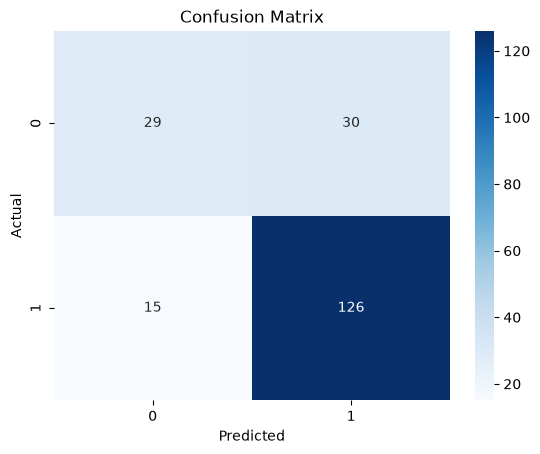

In [104]:
# ===============================
# 9. МАТРИЦА ОШИБОК
# ===============================
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

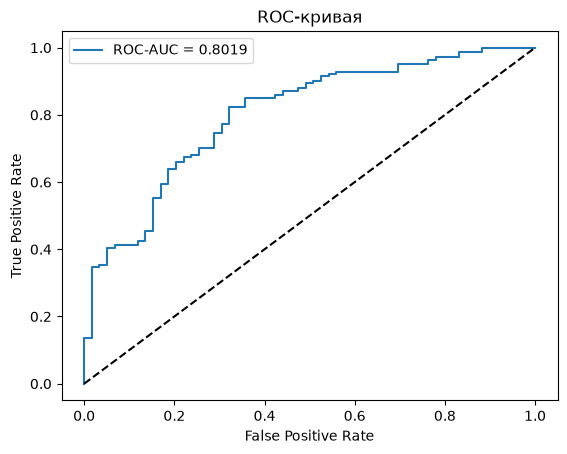

In [105]:
# ===============================
# 10. ROC-КРИВАЯ
# ===============================
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_proba):.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC-кривая')
plt.show()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [59]:
data = fetch_openml(data_id=31, as_frame=True)
df = data.frame
y = data.target.map({'good': 1, 'bad': 0}).astype(int)

X = df.drop(columns=['class'])  

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
num_cols = X.select_dtypes(include=['float64','int64']).columns.tolist()
cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
num_cols

['duration',
 'credit_amount',
 'installment_commitment',
 'residence_since',
 'age',
 'existing_credits',
 'num_dependents']

In [61]:
cat_cols

['checking_status',
 'credit_history',
 'purpose',
 'savings_status',
 'employment',
 'personal_status',
 'other_parties',
 'property_magnitude',
 'other_payment_plans',
 'housing',
 'job',
 'own_telephone',
 'foreign_worker']

In [62]:
preprocessor = ColumnTransformer([
    ('num','passthrough',num_cols),
    ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat_cols)
])

In [63]:
pipeline_rf = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(random_state=42,n_jobs=-1))
])

In [64]:
pipeline_rf.fit(X_train,y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:,1]

In [65]:
print("="*60)
print("RANDOM FOREST (ПО УМОЛЧАНИЮ)")
print("="*60)
print(f"Accuracy: {pipeline_rf.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST (ПО УМОЛЧАНИЮ)
Accuracy: 0.7750
ROC-AUC: 0.8079

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.44      0.54        59
           1       0.80      0.91      0.85       141

    accuracy                           0.78       200
   macro avg       0.74      0.68      0.69       200
weighted avg       0.76      0.78      0.76       200



In [66]:
rf_model = pipeline_rf.named_steps['classifier']
rf_model

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [67]:
cat_feature_names = list(pipeline_rf.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .get_feature_names_out(cat_cols))

In [68]:
all_feature_names = num_cols + cat_feature_names
all_feature_names

['duration',
 'credit_amount',
 'installment_commitment',
 'residence_since',
 'age',
 'existing_credits',
 'num_dependents',
 'checking_status_0<=X<200',
 'checking_status_<0',
 'checking_status_>=200',
 'checking_status_no checking',
 'credit_history_all paid',
 'credit_history_critical/other existing credit',
 'credit_history_delayed previously',
 'credit_history_existing paid',
 'credit_history_no credits/all paid',
 'purpose_business',
 'purpose_domestic appliance',
 'purpose_education',
 'purpose_furniture/equipment',
 'purpose_new car',
 'purpose_other',
 'purpose_radio/tv',
 'purpose_repairs',
 'purpose_retraining',
 'purpose_used car',
 'savings_status_100<=X<500',
 'savings_status_500<=X<1000',
 'savings_status_<100',
 'savings_status_>=1000',
 'savings_status_no known savings',
 'employment_1<=X<4',
 'employment_4<=X<7',
 'employment_<1',
 'employment_>=7',
 'employment_unemployed',
 'personal_status_female div/dep/mar',
 'personal_status_male div/sep',
 'personal_status_mal

In [69]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]


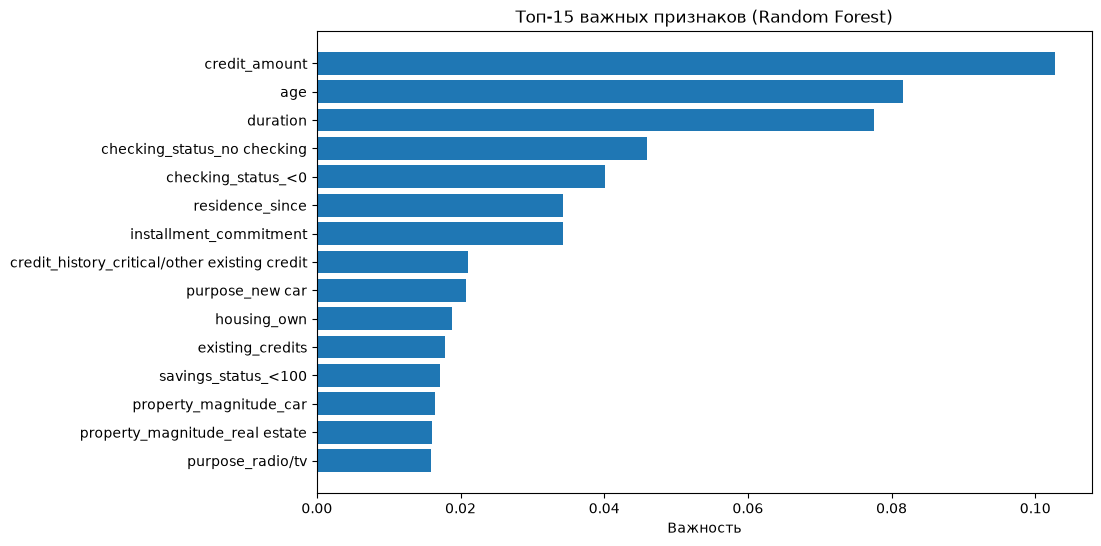

In [70]:
plt.figure(figsize=(10, 6))
plt.title("Топ-15 важных признаков (Random Forest)")
plt.barh(range(15), importances[indices][::-1], align='center')
plt.yticks(range(15), [all_feature_names[i] for i in indices[::-1]])
plt.xlabel("Важность")
plt.show()

In [71]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__max_features': ['sqrt', 'log2']
}


In [72]:
grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... version

In [73]:
print("\n" + "="*60)
print("RANDOM FOREST (ПОСЛЕ GRIDSEARCH)")
print("="*60)
print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_rf.best_score_:.4f}")



RANDOM FOREST (ПОСЛЕ GRIDSEARCH)
Лучшие параметры: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
Лучший ROC-AUC (CV): 0.7903


In [74]:
y_pred_grid = grid_rf.predict(X_test)
y_proba_grid = grid_rf.predict_proba(X_test)[:, 1]
print(f"Тестовый ROC-AUC: {roc_auc_score(y_test, y_proba_grid):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_grid))


Тестовый ROC-AUC: 0.8247

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.39      0.53        59
           1       0.79      0.96      0.87       141

    accuracy                           0.80       200
   macro avg       0.81      0.68      0.70       200
weighted avg       0.80      0.80      0.77       200



In [75]:
pipeline_et = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',ExtraTreesClassifier(random_state=42,n_jobs=-1))
])

In [76]:
pipeline_et.fit(X_train, y_train)
y_proba_et = pipeline_et.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("EXTRA TREES (ПО УМОЛЧАНИЮ)")
print("="*60)
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_et):.4f}")



EXTRA TREES (ПО УМОЛЧАНИЮ)
ROC-AUC: 0.8265


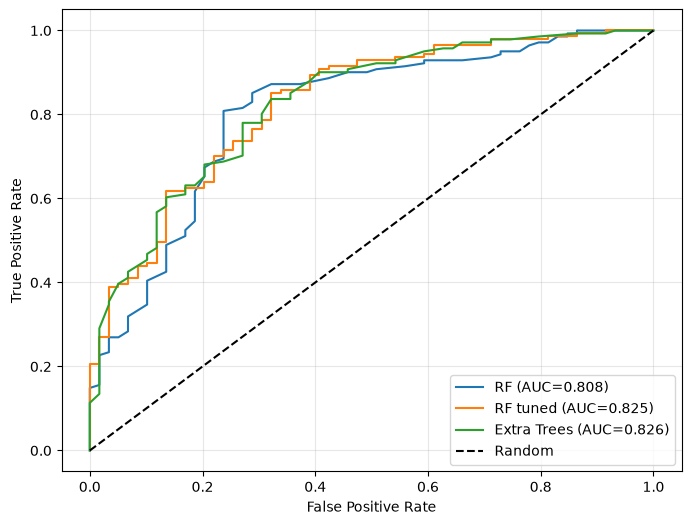

In [77]:
plt.figure(figsize=(8, 6))
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_grid, tpr_grid, _ = roc_curve(y_test, y_proba_grid)
fpr_et, tpr_et, _ = roc_curve(y_test, y_proba_et)

plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test, y_proba_rf):.3f})')
plt.plot(fpr_grid, tpr_grid, label=f'RF tuned (AUC={roc_auc_score(y_test, y_proba_grid):.3f})')
plt.plot(fpr_et, tpr_et, label=f'Extra Trees (AUC={roc_auc_score(y_test, y_proba_et):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()